

## Objetivo.
Este proyecto esta pensado como una extensión del proyecto anterior a donde se analizaba la presencia o ausencia de estres en comentarios de subreddits enfocados en la salud mental, esta vez se quiere ampliar la deteccion a un modelo que maneje multiples emociones en el lenguaje escrito. Ademas se hizo una extension que devuelve las emociones a partir de imagenes de rostros de personas.

## Detector de emociones.

Se ha utilizado un conjunto de datos que recopila datos de diferentes fuentes incluyendo redes sociales, se usan para entrenar modelos que permiten la clasificación de diferentes emociones basado en la rueda de Plutchik, su nombre original en ingles es HRECPW (Hispanic Responses for Emotional Classification based on Plutchik Wheel)    

A continuación, se procede con el análisis de los datos y la implementación del modelo de detección de emociones.

In [1]:
#Importamos las librerias que vamos a necesitar.
import pandas as pd
import numpy as np
import io
import nltk
import re
import string
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Definimos las rutas locales (asegúrate de que los archivos estén en la carpeta Data)
train_path = 'Data/train.parquet'
val_path = 'Data/validation.parquet'

# 2. Reemplazamos la lectura de Colab por lectura directa del archivo
# Usamos engine='pyarrow' porque es el que mejor maneja este formato
df_tain = pd.read_parquet(train_path, engine='pyarrow')
df_val = pd.read_parquet(val_path, engine='pyarrow')

# 3. Unimos los datasets formando un nuevo dataframe (tu lógica original)
df = pd.concat([df_tain, df_val], ignore_index=True)

# 4. Verificaciones (usamos head() con paréntesis para que se vea como tabla)
print("--- Set de Entrenamiento ---")
print(df_tain.head())

print("\n--- Set de Validación ---")
print(df_val.head())

print("\n--- Dataset Unido (Final) ---")
print(df.head())

# Verificamos el tamaño total para estar seguros
print(f"\nTotal de registros combinados: {len(df)}")

--- Set de Entrenamiento ---
                                               texto    etiqueta
0  Encontré una receta que hará que cocinar sopa ...  admiración
1  No podía creerlo cuando vi que mi película fav...    sorpresa
2  Con una actitud optimista, somos capaces de ve...   optimismo
3  Vi a un amigo que no había visto en mucho tiem...      afecto
4  El día con mi amiga me siento muy feliz. Recue...      afecto

--- Set de Validación ---
                                               texto etiqueta
0   AYER FUI DE COMPRAS... COMPRE MUCHOS JUGUETES...   afecto
1   siento que ser fiel no es suficiente en tus o...   afecto
2             mi esposo fue liberado de la cárcel.\n   afecto
3  Tengo que tomarme el día libre de mi trabajo d...   afecto
4        Ayer fue el cuarto cumpleaños de mi hijo.\n   afecto

--- Dataset Unido (Final) ---
                                               texto    etiqueta
0  Encontré una receta que hará que cocinar sopa ...  admiración
1  No podía creerlo c

In [3]:
#Observamos la cantidad de observaciones y caracteristicas del dataset (filas y columnas).
df.shape

(123908, 2)

In [4]:
#Vemos los nombres de todas las columnas del dataset.
df.columns.values

<ArrowStringArray>
['texto', 'etiqueta']
Length: 2, dtype: str

In [5]:
#Nos fijamos si hay nulos en el dataset.
print(df.isnull().sum())

texto       0
etiqueta    0
dtype: int64


In [6]:
# Obtener emociones únicas
emociones_unicas = df['etiqueta'].unique()

# Convertir a lista si es necesario
lista_emociones = emociones_unicas.tolist()

print(lista_emociones)

# Contar la frecuencia de cada emoción
frecuencia_emociones = df['etiqueta'].value_counts()

# Mostrar el resultado
print(frecuencia_emociones)

['admiración', 'sorpresa', 'optimismo', 'afecto', 'ira', 'miedo', 'tristeza', 'calma', 'alegría', 'odio', 'asco']
etiqueta
sorpresa      11347
alegría       11315
miedo         11310
odio          11271
calma         11269
afecto        11256
optimismo     11253
tristeza      11232
asco          11226
admiración    11224
ira           11205
Name: count, dtype: int64


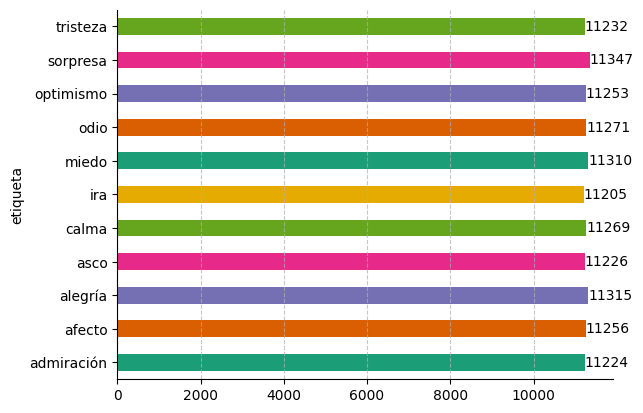

In [8]:
from matplotlib import pyplot as plt
import seaborn as sns

ax = df.groupby('etiqueta').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
# Hacer visibles las líneas de cuadrícula
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir etiquetas con los valores en cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_width()}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center')

# Configurar la visibilidad de los bordes
plt.gca().spines[['top', 'right']].set_visible(False)

# Mostrar el gráfico
plt.show()

In [9]:
#Limpiamos la columna de texto de palabras vacias, enlaces, simbolos especiales y errores del idioma.
from nltk.corpus import stopwords

#Descargamos las stopwords de NLTK.
nltk.download('stopwords')

#Definimos las stopwords
stopwords = set(stopwords.words('spanish'))

# El agregado inferior era apropiado para un dataset anterior que no nos resulto tan efectivo
# Agrego stopwords que no estan en español y propios del dataset usado
# stopwords.update(['hashtag', 'url', 'user'])

#Definimos la función de limpieza.
def clean(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)  #Eliminamos texto entre corchetes.
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  #Eliminamos URLs.
    text = re.sub(r'<.*?>+', '', text)  #Eliminamos etiquetas HTML.
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  #Eliminamos puntuación.
    text = re.sub(r'\n', '', text)  #Eliminamos saltos de línea.
    text = re.sub(r'\w*\d\w*', '', text)  #Eliminamos palabras que contienen números.
    text = [word for word in text.split(' ') if word not in stopwords]  # Eliminar stopwords.
    text = " ".join(text)
    return text

#Aplicamos la función de limpieza a la columna 'text'.
df["texto"] = df["texto"].apply(clean)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jazmi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


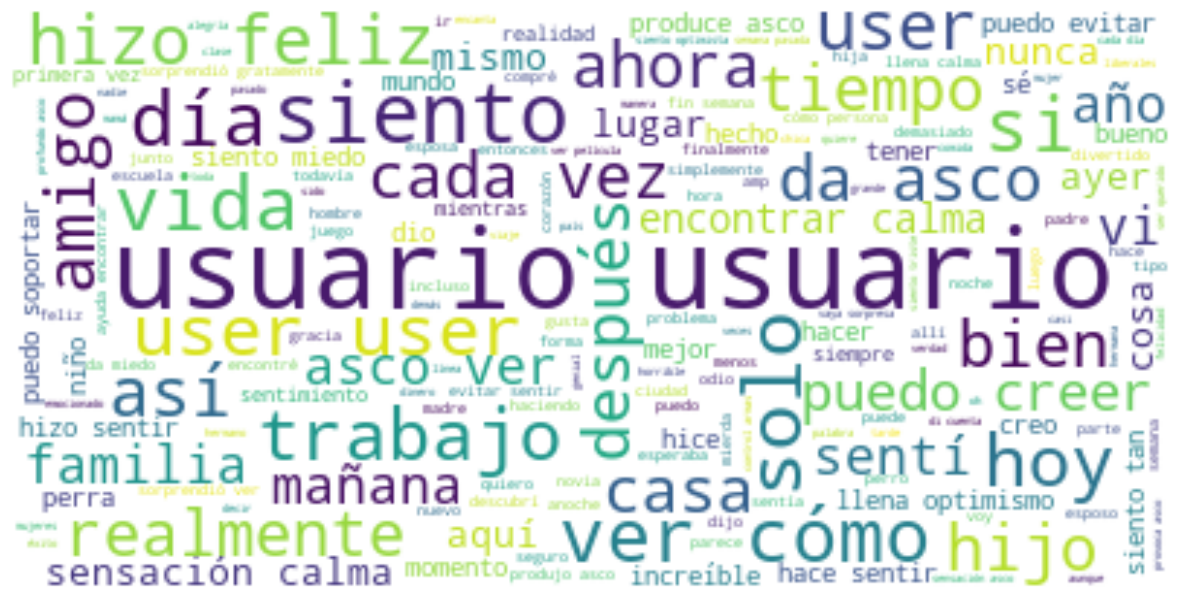

In [10]:
#Analizamos las palabras mas utilizadas por
#las personas que comparten los problemas diarios de sus vidas en las redes sociales.
from wordcloud import WordCloud, ImageColorGenerator

text = " ".join(i for i in df.texto)

wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure(figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [11]:
#MODELO DE DETECCION DE EMOCIONES

# Como vimos la columna "texto" tiene el texto analizado y
# la columna de "etiqueta" contiene etiquetas de las diferentes emociones encontradas.
data = df[["texto", "etiqueta"]]

#Observamos los cambios.
data.head()

,texto,etiqueta
0,encontré receta hará cocinar sopa fideos pollo...,admiración
1,podía creerlo vi película favorita pasando cin...,sorpresa
2,actitud optimista capaces ver oportunidades so...,optimismo
3,vi amigo visto tiempo salí,afecto
4,día amiga siento feliz recuerdo todas cosas pa...,afecto


In [12]:
#Dividimos el dataset en training y test sets.
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

x = np.array(data["texto"])
y = np.array(data["etiqueta"])

cv = CountVectorizer()
X = cv.fit_transform(x)
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=33)

In [13]:
# Entrenamos el modelo de detección de estrés con MultinomialNB que es mejor cuando tenemos varios resultados posibles,
# Usariamos BernoulliNB en caso que los resultados esperados sean binarios
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(xtrain, ytrain)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [14]:
#score del modelo
print(model.score(xtest, ytest))

0.798361714147365


In [15]:
#Ahora probamos el rendimiento de nuestro modelo en algunas oraciones
#aleatorias basadas en la salud mental.

# Pruebas para "alegría"  : hay que disfrutar de la vida tal como es |
# Pruebas para "optimismo": hoy hice deporte
# Pruebas para "tristeza" : la vida de muchos es una triste historia gris |
# Pruebas para "ira"      : No soy una persona religiosa, pero lo de Notre Dame va más allá | la lectura hace que las personas se desarrollen en paz
# Pruebas para "odio"     : La gente, necesita cuidar su salud mental? |

user = input("Ingrese una frase: ")
data = cv.transform([user]).toarray()
output = model.predict(data)
print(output)

['alegría']




---


## Detector de emociones en imagenes.

Este scrip nos permite cargar una imagen, detectar rostros y analizar las emociones en las caras detectadas utilizando herramientas de visión por computadora y aprendizaje profundo.

**Nuevo Módulo: Análisis de Imágenes y sus emociones.**

In [1]:
# Instalar las librerías necesarias
!pip install opencv-python-headless matplotlib
!pip install deepface

# Importar las librerías necesarias para el análisis de imágenes y emociones

import os

# OpenCV: Biblioteca para procesamiento de imágenes, se usa para leer y manipular imágenes
import cv2

# Matplotlib: Librería para crear gráficos y visualizar imágenes
import matplotlib.pyplot as plt

# DeepFace: Framework de análisis facial que permite detectar emociones, edad, género y más
from deepface import DeepFace


26-04-29 21:54:05 - Directory C:\Users\jazmi\.deepface has been created
26-04-29 21:54:05 - Directory C:\Users\jazmi\.deepface\weights has been created


In [2]:
# Modificamos la función para que busque fotos en tu carpeta local 'Imagenes'
def obtener_imagen_local():
    # Listamos los archivos de la carpeta Imagenes
    fotos = [f for f in os.listdir('Data/imagenes') if f.endswith(('.jpg', '.png', '.jpeg'))]
    if fotos:
        print(f"Imagen encontrada: {fotos[0]}")
        return os.path.join('Data/imagenes', fotos[0]) # Retorna la ruta de la primera foto
    else:
        print("No hay fotos en la carpeta 'Data/imagenes'")
        return None

In [16]:
# --- BLOQUE: SELECCIÓN MANUAL DE IMAGEN ---

def seleccionar_imagen_manual():
    # 1. Listamos las imágenes disponibles en la carpeta
    archivos = [f for f in os.listdir('Data/imagenes') if f.endswith(('.jpg', '.png', '.jpeg'))]
    
    if not archivos:
        print("❌ No se encontraron imágenes en la carpeta 'Data/imagenes'.")
        return None

    # 2. Te mostramos la lista para que sepas cuáles tenés
    print("Imágenes disponibles en la carpeta:")
    for i, foto in enumerate(archivos):
        print(f"[{i}] {foto}")

    # 3. AQUÍ ELEGÍS VOS: 
    # Podés cambiar el número '0' por el índice de la foto que quieras (0, 1, 2, 3...)
    indice_elegido = 2 
    
    nombre_elegido = archivos[indice_elegido]
    print(f"\n👉 Has seleccionado: {nombre_elegido}")
    return os.path.join('Data/imagenes', nombre_elegido)

# Llamamos a la función
image_path = seleccionar_imagen_manual()

Imágenes disponibles en la carpeta:
[0] Imagen_01.png
[1] Imagen_02.png
[2] Imagen_03.png
[3] Imagen_04.png

👉 Has seleccionado: Imagen_03.png


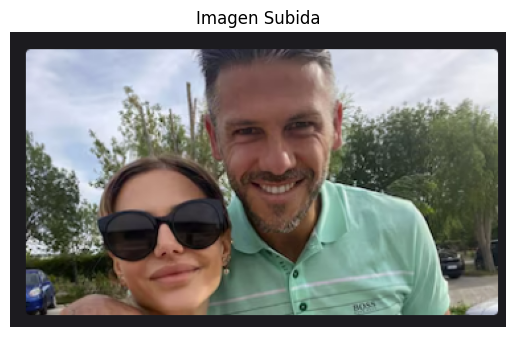

In [17]:
# Cargar la imagen desde la ruta proporcionada
# La imagen se carga en formato BGR, que es el formato predeterminado de OpenCV
image = cv2.imread(image_path)

# Convertir la imagen de formato BGR a RGB
# Esto es necesario porque OpenCV utiliza BGR, mientras que Matplotlib usa RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Mostrar la imagen utilizando Matplotlib en formato RGB
plt.imshow(image_rgb)

# Desactivar los ejes para una visualización más limpia
plt.axis('off')

# Agregar un título a la imagen
plt.title('Imagen Subida')

# Mostrar la imagen con el título en pantalla
plt.show()

In [18]:
# Detección Facial

# Cargar modelo preentrenado de detección facial
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [19]:
# Convertir imagen a escala de grises para el modelo
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [20]:
# Detectar caras en la imagen
faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

In [21]:
# Dibujar rectángulos alrededor de las caras detectadas
for (x, y, w, h) in faces:
    cv2.rectangle(image_rgb, (x, y), (x+w, y+h), (255, 0, 0), 3)

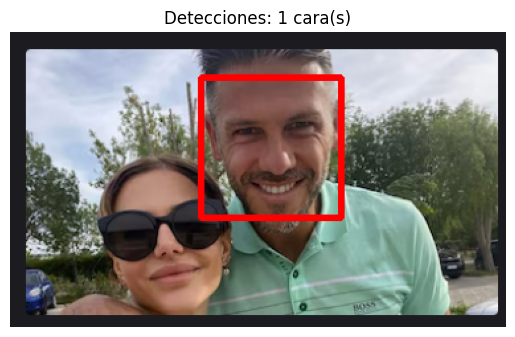

In [22]:
# Mostrar la imagen con las detecciones de caras resaltadas
# 'image_rgb' contiene la imagen en formato RGB con los rectángulos dibujados alrededor de las caras detectadas
plt.imshow(image_rgb)

# Desactivar los ejes para que la visualización sea más limpia
plt.axis('off')

# Agregar un título indicando la cantidad de caras detectadas en la imagen
# Se utiliza f-string para incluir dinámicamente el número de caras detectadas
plt.title(f'Detecciones: {len(faces)} cara(s)')

# Mostrar la imagen con el título en pantalla
plt.show()

In [23]:
# Mensaje sobre las detecciones
if len(faces) > 0:
    print(f"Se detectaron {len(faces)} cara(s) en la imagen.")
else:
    print("No se detectaron caras en la imagen.")

Se detectaron 1 cara(s) en la imagen.


In [24]:
# Análisis Emocional con DeepFace

# Definir una función para analizar las emociones presentes en una imagen
# La función toma como entrada 'frame', que es el marco o imagen a analizar
def analizar_emociones(frame):
    try:
        # Utilizar la biblioteca DeepFace para analizar la imagen y detectar emociones
        # 'actions=['emotion']' indica que solo se analizarán emociones
        # 'enforce_detection=False' permite analizar imágenes incluso si no se detectan rostros con certeza
        resultado = DeepFace.analyze(frame, actions=['emotion'], enforce_detection=False)

        # Extraer el diccionario de emociones del resultado
        emociones = resultado[0]['emotion']  # Corregido para acceder correctamente al diccionario de emociones

        # Determinar la emoción principal identificada, basada en la confianza más alta
        emocion_principal = max(emociones, key=emociones.get)

        # Retornar un mensaje que indique la emoción principal detectada y su nivel de confianza
        return f"Emoción detectada: {emocion_principal} (confianza: {emociones[emocion_principal]:.2f}%)"

    except Exception as e:
        # Manejar excepciones en caso de que ocurra un error durante el análisis
        return f"Hubo un problema al analizar emociones: {e}"

In [25]:
# Llamar al análisis emocional solo si se detectaron caras en la imagen
if len(faces) > 0:  # Comprobar si el número de caras detectadas es mayor a 0
    # Si se detectaron caras, realizar el análisis emocional en la imagen
    emocion_detectada = analizar_emociones(image_path)

    # Imprimir el resultado del análisis emocional
    print(emocion_detectada)
else:
    # Si no se detectaron caras, informar que no se puede realizar el análisis emocional
    print("No se detectaron caras para realizar el análisis emocional.")

Emoción detectada: happy (confianza: 99.82%)




---


## Informe final

En la primera seccion de clasifiacion de texto si bien el dataset es grande y el score obtenido es bastante bueno, los resultados a veces no predicen exactamente lo que se espera pero son buenos en general, previo a este hemos probado con otro dataset tambien basado en comentarios de redes sociales y las predicciones caian muchas veces en el mismo resultado, eso motivo a un cambio y reestructura del codigo para que se adapte al dataset finalmente usado.

En la seccion de deteccion de emociones basadas en imagenes se oberva que si bien la herramienta elegida para la deteccion internamente hace uso de otras herramientas segun necesite, los resultados muchas veces carecen de precision, en algunos casos detecta rostros donde no los hay y otras veces a un rostro que se ve claramente no lo detecta, por lo consiguiente se pierde el analisis de la emoción expresada por el rostro.

Fuentes de datos:

https://huggingface.co/datasets/BrunoGR/HRECPW-Hispanic_Responses_for_Emotional_Classification_based_on_Plutchik_Wheel

Las imagenes que se usaron para este trabajo fueron extraidas de medios de noticias online.